# Copernicus Solar Forecasting - Notebook de rendu final

Objectif: prédire les cartes futures de GHI à 15, 30, 45 et 60 minutes sur une RoI 51 x 51 pixels à partir de séquences satellites.

La référence principale est la persistance du clear-sky index (`persistence_csi_baseline`). Les modèles supervisés sont considérés intéressants seulement si leur skill score RMSE est positif face à cette baseline.

## 0. Setup & Chargement

Cette section charge la configuration du projet, les données préparées et crée un split chronologique train / validation. Le profil `dev` permet de vérifier le notebook rapidement; passer à `sample`, puis `full`, pour produire les résultats finaux.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import ParameterGrid
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import FORECAST_HORIZONS_MINUTES, INPUT_VARIABLES
from src.baselines import (
    mean_image_baseline,
    persistence_csi_baseline,
    persistence_last_ghi_baseline,
)
from src.data_loading import (
    open_processed_profile,
    prepare_processed_profile,
    processed_profile_exists,
)
from src.deep_learning import (
    add_residual_mean_to_baseline,
    fit_mlp_residual_mean,
    has_tensorflow,
    prepare_cnn_training_data,
    build_small_residual_cnn,
    target_from_channels_last,
)
from src.eda import descriptive_stats, target_horizon_stats
from src.features import (
    build_advanced_features,
    build_physical_inputs,
    build_spatial_feature_tensor,
    build_tabular_features,
)
from src.interpretation import (
    compute_tree_shap_values,
    model_feature_importances,
    permutation_importance_multioutput,
)
from src.metrics import (
    evaluate_by_horizon,
    evaluate_forecasts,
    evaluate_spatial_means,
    evaluate_spatial_structure,
    evaluate_by_horizon_detailed,
    build_model_diagnostics,
    forecast_skill_score,
    rmse,
    skill_score_from_rmse,
    global_metrics_row,
    spatial_mean_residual,
    cluster_quality,
    cluster_balance_report,
    metrics_by_cluster,
)
from src.preprocessing import temporal_train_validation_split
from src.visualization import horizon_titles, plot_sequence
from models.models_tabular import (
    fit_elasticnet_multioutput,
    fit_random_forest_multioutput,
    fit_extra_trees_multioutput,
    fit_ridge_multioutput,
    fit_hist_gb_multioutput,
)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
PROFILE = "full"
RUN_FAST = PROFILE == "dev"
np.random.seed(RANDOM_STATE)

RUN_RIDGE = True
RUN_ELASTICNET = PROFILE in {"dev", "sample"}   # à retirer sur full
RUN_RANDOM_FOREST = PROFILE in {"dev", "sample"}
RUN_EXTRA_TREES = True
RUN_HGB = True

SHOW_WEAK_BASELINES_IN_FINAL_TABLE = False
MAIN_REFERENCE_NAME = "persistence_csi"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
if not processed_profile_exists(PROFILE, split="train"):
    prepare_processed_profile(PROFILE, split="train", overwrite=False)

data = open_processed_profile(PROFILE, split="train", variables=INPUT_VARIABLES, mmap_mode=None)
arrays = {name: np.asarray(values, dtype=np.float32) for name, values in data["X"].items()}
y = np.asarray(data["y"], dtype=np.float32)

train_idx, val_idx = temporal_train_validation_split(len(y), validation_fraction=0.2)
train_arrays_raw = {name: values[train_idx] for name, values in arrays.items()}
val_arrays_raw = {name: values[val_idx] for name, values in arrays.items()}
train_target = y[train_idx]
val_target = y[val_idx]

print(f"Profil: {PROFILE}")
print(f"Samples: total={len(y)}, train={len(train_idx)}, validation={len(val_idx)}")
print({name: value.shape for name, value in arrays.items()})
print("Target:", y.shape)

Profil: full
Samples: total=1845, train=1476, validation=369
{'GHI': (1845, 4, 51, 51), 'CLS': (1845, 8, 51, 51), 'SZA': (1845, 8, 51, 51), 'SAA': (1845, 8, 51, 51)}
Target: (1845, 4, 51, 51)


## 1. Problématique

Le challenge consiste à prévoir le rayonnement solaire global horizontal (GHI) sur les quatre horizons futurs `t+15`, `t+30`, `t+45` et `t+60` minutes, sous forme de cartes 51 x 51 pixels centrées sur la zone d'intérêt. Les entrées combinent les quatre dernières images GHI, les huit images de GHI clear-sky et les angles solaires SZA/SAA sur une zone d'observation plus large. La stratégie retenue compare une baseline physique forte, la persistance du clear-sky index, à des modèles tabulaires, de clustering, d'interprétation et à une piste deep learning optionnelle.

## 2. EDA

On vérifie les ordres de grandeur, les dimensions et la dynamique par horizon. Sur `dev`, les statistiques servent surtout à contrôler le pipeline; les conclusions métiers doivent être relues sur `sample` ou `full`.

In [4]:
display(descriptive_stats(arrays, y))
display(target_horizon_stats(y))

,variable,shape,mean,std,min,median,max
0,GHI,"(1845, 4, 51, 51)",501.326935,273.921478,8.040000,499.649994,1099.449951
1,CLS,"(1845, 8, 51, 51)",576.162415,253.484070,34.450001,567.429993,1119.270020
2,SZA,"(1845, 8, 51, 51)",175.404953,60.614697,65.910004,173.330002,285.309998
3,SAA,"(1845, 8, 51, 51)",52.772953,17.380068,12.980000,55.619999,85.449997
4,target,"(1845, 4, 51, 51)",510.516968,261.338043,7.330000,472.369995,1093.689941


,horizon_min,mean,std,min,median,max
0,15,511.794189,258.839478,19.34,486.140015,1093.689941
1,30,512.276611,258.324799,14.93,472.820007,1084.849976
2,45,510.756714,261.177277,10.13,457.950012,1077.020020
3,60,507.240509,266.892487,7.33,469.109985,1087.630005


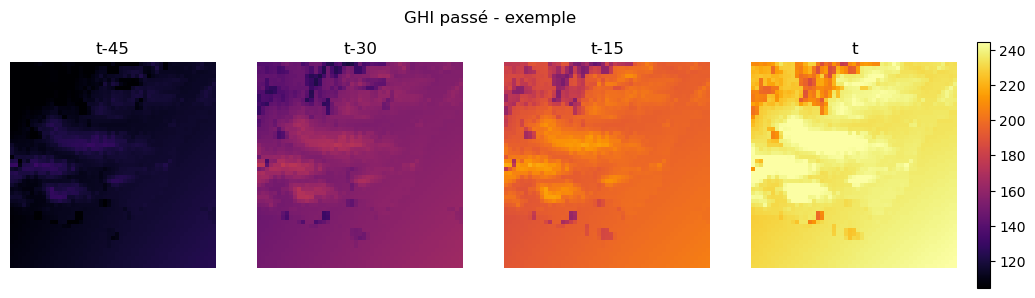

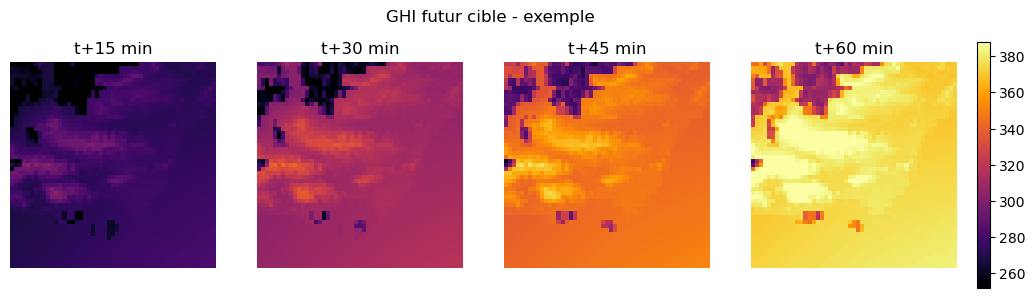

In [5]:
sample_id = 0
plot_sequence(
    arrays["GHI"][sample_id],
    titles=["t-45", "t-30", "t-15", "t"],
    suptitle="GHI passé - exemple",
)
plt.show()

plot_sequence(
    y[sample_id],
    titles=horizon_titles(),
    suptitle="GHI futur cible - exemple",
)
plt.show()

### Interprétation des statistiques descriptives

Les niveaux moyens de `GHI` observé et de la cible future sont proches, ce qui suggère l'absence de rupture majeure entre les entrées et les sorties à cette échelle. En revanche, l'écart-type de la cible augmente avec l'horizon de prévision : les horizons lointains sont donc plus difficiles à prédire que les horizons courts.

Ce comportement est cohérent avec un problème de nowcasting : plus on s'éloigne dans le futur, plus l'incertitude liée au déplacement et à l'évolution des nuages augmente.

## 3. Features

Les features mélangent une représentation physique (`CSI`, `CLS`, angles encodés en sinus/cosinus) et des résumés tabulaires robustes: moyennes, écarts-types, quantiles, tendances temporelles et moyennes par quadrant. L'idée est de donner aux modèles classiques une vision compacte des conditions météo et solaires sans aplatir les 10 404 pixels de la cible.

In [6]:
train_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=True, encode_angles=True)
val_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)

X_train_features = pd.concat(
    [
        build_tabular_features(train_phys).add_prefix("phys_"),
        build_advanced_features(train_arrays_raw).add_prefix("adv_"),
    ],
    axis=1,
)
X_val_features = pd.concat(
    [
        build_tabular_features(val_phys).add_prefix("phys_"),
        build_advanced_features(val_arrays_raw).add_prefix("adv_"),
    ],
    axis=1,
)

common_cols = [col for col in X_train_features.columns if col in X_val_features.columns]
X_train_features = X_train_features[common_cols].replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features[common_cols].replace([np.inf, -np.inf], np.nan)
medians = X_train_features.median(numeric_only=True).fillna(0.0)
X_train_features = X_train_features.fillna(medians)
X_val_features = X_val_features.fillna(medians)

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(X_train_features).astype(np.float32)
X_val_tab = scaler.transform(X_val_features).astype(np.float32)
feature_names = list(X_train_features.columns)

print("Feature matrix train:", X_train_tab.shape)
display(X_train_features.describe().T.head(20))

Feature matrix train: (1476, 565)


,count,mean,std,min,25%,50%,75%,max
phys_CSI_mean_t0,1476.0,0.880412,0.124901,0.143136,0.846034,0.921615,0.964935,1.002780
phys_CSI_std_t0,1476.0,0.082471,0.069276,0.001421,0.024556,0.063255,0.127203,0.317049
phys_CSI_min_t0,1476.0,0.527376,0.259031,0.093864,0.292224,0.536363,0.757906,0.982073
phys_CSI_max_t0,1476.0,0.964526,0.043581,0.446953,0.957681,0.976410,0.991968,1.020442
phys_CSI_mean_t1,1476.0,0.880345,0.128423,0.147248,0.844999,0.922198,0.965784,1.002667
phys_CSI_std_t1,1476.0,0.084777,0.071150,0.001376,0.024935,0.064601,0.132382,0.322224
phys_CSI_min_t1,1476.0,0.520147,0.266480,0.094576,0.268508,0.535634,0.752697,0.981175
phys_CSI_max_t1,1476.0,0.967008,0.039864,0.475089,0.956523,0.976917,0.991954,1.019928
phys_CSI_mean_t2,1476.0,0.881551,0.128337,0.153504,0.848248,0.922083,0.965704,1.002711
phys_CSI_std_t2,1476.0,0.085331,0.071600,0.001110,0.025301,0.066161,0.131844,0.316081


In [7]:
spatial_train_tensor, spatial_feature_names = build_spatial_feature_tensor(train_phys)
print("Tenseur spatial pour CNN:", spatial_train_tensor.shape)
print("Premiers canaux:", spatial_feature_names[:12])

Tenseur spatial pour CNN: (1476, 51, 51, 51)
Premiers canaux: ['CSI_t0', 'CSI_t1', 'CSI_t2', 'CSI_t3', 'CLS_t0', 'CLS_t1', 'CLS_t2', 'CLS_t3', 'CLS_t4', 'CLS_t5', 'CLS_t6', 'CLS_t7']


### Justification des features retenues

Nous construisons les variables explicatives à partir d'une représentation physiquement informée du problème. Le `CLS` fournit une référence théorique sans nuage, tandis que le `CSI = GHI / CLS` isole plus directement l'effet nuageux.

Les angles solaires sont encodés via des couples `sin/cos` afin de respecter leur nature circulaire. Enfin, nous complétons ces variables physiques par des résumés spatiaux et temporels (moyennes, écarts-types, quantiles, tendances), adaptés aux modèles tabulaires.

## 4. Baselines

La baseline principale est la persistance CSI: on conserve le dernier clear-sky index observé et on le multiplie par le clear-sky futur connu. C'est une référence plus exigeante que la persistance brute du dernier GHI.

In [8]:
y_pred_persistence_raw = persistence_last_ghi_baseline(val_arrays_raw)
y_pred_persistence_csi = persistence_csi_baseline(val_arrays_raw)
y_pred_mean = mean_image_baseline(train_target, n_samples=len(val_target))

y_pred_train_csi = persistence_csi_baseline(train_arrays_raw)

predictions = {
    "persistence_raw": y_pred_persistence_raw,
    "persistence_csi": y_pred_persistence_csi,
    "mean_image": y_pred_mean,
}

csi_reference_rmse = rmse(val_target, y_pred_persistence_csi)
baseline_table = pd.DataFrame(
    [
        global_metrics_row(name, val_target, pred, csi_reference_rmse)
        for name, pred in predictions.items()
    ]
).sort_values("RMSE")
display(baseline_table)

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
1,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
0,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
2,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


- la persistance brute échoue parce qu’elle suppose que l’image future est identique à l’image présente;
- la persistance CSI marche beaucoup mieux parce qu’elle suppose seulement que le facteur nuageux relatif reste stable, puis le réinjecte dans le CLS futur;
- la mean image baseline est volontairement très faible : elle sert juste de borne basse.

### Analyse des baselines

La baseline `persistence_csi` constitue une référence forte pour ce problème. Contrairement à la persistance brute, elle ne suppose pas que l'image future est identique à l'image présente, mais que l'effet nuageux relatif (capté par le clear-sky index) persiste à court terme, puis est réinjecté dans le champ `CLS` futur.

Sur le run `full`, `persistence_csi` atteint un RMSE global de **44.07**, très inférieur à la persistance brute et à l'image moyenne (de 83.52 et 282.07 respectivement). Cela confirme que la physique du problème explique déjà une grande partie du signal, et que les modèles supervisés doivent surtout apprendre une **correction** au-dessus de cette baseline, plutôt qu'une prédiction entièrement libre.

Cette baseline sera donc utilisée comme référence principale dans toute la suite de l'analyse.

## 5. Clustering non supervisé

Le clustering sert à segmenter les régimes de ciel: couvert, partiellement nuageux et ciel clair. Il ne remplace pas la prédiction supervisée; il permet surtout de voir dans quels régimes la baseline ou les modèles se dégradent.

Métriques utiles ici:

- qualité du clustering: silhouette, Calinski-Harabasz, Davies-Bouldin;
- performance par cluster: RMSE, MAE, biais moyen, nRMSE, erreur absolue P90;
- skill score par cluster face à la persistance CSI;
- taille du cluster, car un bon score sur un petit régime est fragile.

In [9]:
cluster_feature_candidates = [
    col for col in feature_names
    if any(token in col for token in ["CSI_mean", "CSI_std", "CSI_trend", "GHI_mean", "GHI_std", "adv_csi"])
]
cluster_feature_names = cluster_feature_candidates if len(cluster_feature_candidates) >= 3 else feature_names

X_cluster_train = X_train_features[cluster_feature_names].to_numpy(dtype=np.float32)
X_cluster_val = X_val_features[cluster_feature_names].to_numpy(dtype=np.float32)

cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_val_scaled = cluster_scaler.transform(X_cluster_val)

cluster_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_cluster_train_emb = cluster_pca.fit_transform(X_cluster_train_scaled)
X_cluster_val_emb = cluster_pca.transform(X_cluster_val_scaled)

k_values = [2, 3] if RUN_FAST else [2, 3, 4, 5]
cluster_search_rows = []
best_cluster_score = -np.inf
best_kmeans = None
best_k = None

min_cluster_size_required = max(8, int(0.05 * len(X_cluster_train_emb)))

for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    train_labels = km.fit_predict(X_cluster_train_emb)

    quality = cluster_quality(X_cluster_train_emb, train_labels)
    quality_map = dict(zip(quality["metric"], quality["value"])) if not quality.empty else {}

    counts = pd.Series(train_labels).value_counts()
    min_cluster_size = int(counts.min())
    max_cluster_share = float((counts / counts.sum()).max())

    row = {
        "k": k,
        "silhouette": quality_map.get("silhouette", np.nan),
        "calinski_harabasz": quality_map.get("calinski_harabasz", np.nan),
        "davies_bouldin": quality_map.get("davies_bouldin", np.nan),
        "min_cluster_size": min_cluster_size,
        "max_cluster_share": max_cluster_share,
    }
    cluster_search_rows.append(row)

    valid_partition = min_cluster_size >= min_cluster_size_required
    score = row["silhouette"] if valid_partition else -np.inf
    if score > best_cluster_score:
        best_cluster_score = score
        best_kmeans = km
        best_k = k

cluster_search = pd.DataFrame(cluster_search_rows).sort_values("silhouette", ascending=False)
display(cluster_search)
print("Best k:", best_k)

train_clusters = best_kmeans.predict(X_cluster_train_emb)
val_clusters = best_kmeans.predict(X_cluster_val_emb)

display(cluster_balance_report(train_clusters))
display(cluster_balance_report(val_clusters))

cluster_frame = X_val_features.copy()
cluster_frame["cluster"] = val_clusters

csi_cols = [col for col in cluster_frame.columns if "CSI_mean_t3" in col or "csi_last_frame_mean" in col]
csi_label_col = csi_cols[0] if csi_cols else cluster_feature_names[0]

cluster_summary = (
    cluster_frame
    .groupby("cluster")
    .agg(n=(csi_label_col, "size"), csi_level=(csi_label_col, "mean"))
    .sort_values("csi_level")
)
ordered_clusters = list(cluster_summary.index)
weather_names = ["couvert", "partiellement_nuageux", "ciel_clair", "très_clair", "très_variable"]
cluster_name_map = {cluster: weather_names[i] for i, cluster in enumerate(ordered_clusters)}
cluster_summary["regime"] = [cluster_name_map[idx] for idx in cluster_summary.index]
display(cluster_summary.reset_index())

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 101: invalid start byte


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_share
0,2,0.449607,1128.346119,1.035582,425,0.712060
2,4,0.404117,1079.847480,0.975797,110,0.481707
1,3,0.380002,1032.904130,1.037117,295,0.506775
3,5,0.378095,1008.934884,0.992637,93,0.424119


Best k: 2


,cluster,n,share
0,0,425,0.28794
1,1,1051,0.71206


,cluster,n,share
0,0,223,0.604336
1,1,146,0.395664


,cluster,n,csi_level,regime
0,0,223,0.646960,couvert
1,1,146,0.907772,partiellement_nuageux


La recherche du nombre de clusters conduit ici à une solution simple à **2 régimes**. Cette segmentation est cohérente avec une lecture physique du problème : la validation se décompose essentiellement entre des situations **couvertes** et des situations **partiellement nuageuses**. Cela ne signifie pas nécessairement l'absence de situations de ciel dégagé dans les données, mais plutôt que, dans l'espace de features retenu, les cas dégagés ne forment pas un groupe suffisamment distinct pour être séparés des situations faiblement nuageuses. Le cluster interprété comme "partiellement nuageux" doit donc être compris plus largement comme un régime de **faible nébulosité**, pouvant inclure des situations proches du ciel clair.

L'intérêt du clustering n'est pas de produire une prévision directement, mais de montrer que la difficulté du problème dépend fortement du régime météo. 

La prévision court terme n'a pas le même niveau de difficulté selon que le champ radiatif est relativement homogène ou qu'il est fortement perturbé par les nuages.



In [18]:
# --- Diagnostic : le cluster "partiellement nuageux" contient-il du quasi ciel clair ? ---

# Seuil "quasi ciel clair"
CSI_CLEAR_THRESHOLD = 0.95

# On repart des features de validation + labels de cluster
cluster_diag = X_val_features.copy()
cluster_diag["cluster"] = val_clusters

# On choisit une feature CSI représentative de l'état le plus récent
candidate_cols = [col for col in cluster_diag.columns if "phys_CSI_mean_t3" in col]
if len(candidate_cols) == 0:
    raise ValueError("La colonne 'phys_CSI_mean_t3' est introuvable dans X_val_features.")
csi_col = candidate_cols[0]

# Indicateur quasi ciel clair
cluster_diag["is_quasi_clear"] = cluster_diag[csi_col] >= CSI_CLEAR_THRESHOLD

# Statistiques par cluster
quasi_clear_by_cluster = (
    cluster_diag
    .groupby("cluster")
    .agg(
        n=(csi_col, "size"),
        csi_mean=(csi_col, "mean"),
        csi_std=(csi_col, "std"),
        quasi_clear_count=("is_quasi_clear", "sum"),
        quasi_clear_share=("is_quasi_clear", "mean"),
    )
    .reset_index()
)

# Ajout du nom métier si disponible
if "cluster_name_map" in globals():
    quasi_clear_by_cluster["regime"] = quasi_clear_by_cluster["cluster"].map(cluster_name_map)

# Mise en forme
quasi_clear_by_cluster["quasi_clear_share"] = (100 * quasi_clear_by_cluster["quasi_clear_share"]).round(1)

display(quasi_clear_by_cluster.sort_values("csi_mean"))

# Quelques exemples très clairs par cluster
examples_per_cluster = (
    cluster_diag
    .assign(row_id=np.arange(len(cluster_diag)))
    .sort_values([ "cluster", csi_col ], ascending=[True, False])
    .groupby("cluster")
    .head(5)[["cluster", "row_id", csi_col, "is_quasi_clear"]]
)

if "cluster_name_map" in globals():
    examples_per_cluster["regime"] = examples_per_cluster["cluster"].map(cluster_name_map)

display(examples_per_cluster)

,cluster,n,csi_mean,csi_std,quasi_clear_count,quasi_clear_share,regime
0,0,223,0.646960,0.186254,0,0.0,couvert
1,1,146,0.907772,0.047290,27,18.5,partiellement_nuageux


,cluster,row_id,phys_CSI_mean_t3,is_quasi_clear,regime
68,0,68,0.898838,False,couvert
127,0,127,0.883927,False,couvert
52,0,52,0.882460,False,couvert
83,0,83,0.875215,False,couvert
258,0,258,0.874963,False,couvert
18,1,18,0.980144,True,partiellement_nuageux
23,1,23,0.974739,True,partiellement_nuageux
19,1,19,0.972587,True,partiellement_nuageux
91,1,91,0.972567,True,partiellement_nuageux
24,1,24,0.969350,True,partiellement_nuageux


### Interprétation du diagnostic quasi ciel clair

Le diagnostic confirme que le cluster `couvert` correspond bien à un régime fortement perturbé : son `CSI` moyen est faible (`0.647`) et aucun exemple n'atteint le seuil de quasi ciel clair.

Le second cluster présente au contraire un `CSI` moyen élevé (`0.908`) et une faible dispersion, ce qui indique un régime de **faible nébulosité**. En revanche, seuls **18.5 %** des cas de ce cluster dépassent le seuil `CSI_mean_t3 > 0.95`. Cela signifie que ce groupe ne correspond pas à un ciel dégagé pur, mais plutôt à un ensemble plus large allant du **quasi ciel clair** au **partiellement nuageux**.

Ainsi, l'absence d'un cluster explicitement nommé `ciel_dégagé` ne traduit pas une absence de ces situations dans les données : elles existent bien, mais elles sont ici **fusionnées** avec les cas de faible nébulosité dans un même cluster. Le clustering distingue donc surtout deux grands régimes : un régime **couvert** et un régime **clair à partiellement nuageux**.

In [10]:
display(metrics_by_cluster(
    val_target,
    y_pred_persistence_csi,
    val_clusters,
    "persistence_csi",
    cluster_name_map=cluster_name_map,
    reference_pred=y_pred_persistence_csi,
))

,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
0,persistence_csi,0,couvert,223,53.431490,33.184921,-7.104929,86.286774,0.186637,3.502643e-12
1,persistence_csi,1,partiellement_nuageux,146,23.402249,11.831979,1.408314,31.945608,0.058300,1.825939e-11


### Analyse des performances par régime

Les résultats par cluster montrent que le régime **couvert** est nettement plus difficile à prévoir que le régime **partiellement nuageux**. La baseline `persistence_csi` obtient déjà de bonnes performances dans le régime partiellement nuageux, tandis que l'erreur augmente fortement dans le régime couvert.

Les modèles supervisés (`HistGradientBoosting`, `ExtraTrees`) améliorent la baseline CSI dans les deux régimes, mais sans rupture majeure. Cela suggère qu'une partie de l'information utile est bien captée par les features tabulaires, mais que cette représentation reste limitée pour modéliser les configurations spatiales complexes présentes dans les situations très nuageuses.

## 6. Modèles supervisés

Pour garder un entraînement raisonnable, les modèles tabulaires apprennent une correction de la persistance CSI: la cible supervisée est le résidu moyen par horizon, puis cette correction est ajoutée à toute la carte. Ce choix respecte la structure physique forte de la baseline et évite de demander à des modèles tabulaires de prédire directement 10 404 sorties avec peu d'observations.

Modèles testés: Ridge, ElasticNet, Random Forest, ExtraTrees et HistGradientBoosting. HistGB est optimisé par une petite recherche d'hyperparamètres sur une validation chronologique interne.

In [11]:
residual_train = spatial_mean_residual(train_target, y_pred_train_csi)
residual_val = spatial_mean_residual(val_target, y_pred_persistence_csi)

model_registry = {}
supervised_predictions = {}

if RUN_RIDGE:
    ridge_model = fit_ridge_multioutput(X_train_tab, residual_train, alpha=10.0, random_state=RANDOM_STATE)
    ridge_residual = ridge_model.predict(X_val_tab)
    supervised_predictions["ridge_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        ridge_residual,
    )
    model_registry["ridge_residual_csi"] = ridge_model

if RUN_ELASTICNET:
    elastic_model = fit_elasticnet_multioutput(
        X_train_tab,
        residual_train,
        alpha=0.001,
        l1_ratio=0.2,
        random_state=RANDOM_STATE,
        max_iter=2000,
    )
    elastic_residual = elastic_model.predict(X_val_tab)
    supervised_predictions["elasticnet_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        elastic_residual,
    )
    model_registry["elasticnet_residual_csi"] = elastic_model

if RUN_RANDOM_FOREST:
    rf_model = fit_random_forest_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=30 if RUN_FAST else 150,
        max_depth=6 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    rf_residual = rf_model.predict(X_val_tab)
    supervised_predictions["random_forest_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        rf_residual,
    )
    model_registry["random_forest_residual_csi"] = rf_model

if RUN_EXTRA_TREES:
    extra_model = fit_extra_trees_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=40 if RUN_FAST else 200,
        max_depth=8 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    extra_residual = extra_model.predict(X_val_tab)
    supervised_predictions["extra_trees_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        extra_residual,
    )
    model_registry["extra_trees_residual_csi"] = extra_model

### Optimisation de HistGradientBoosting

HistGB s'optimise surtout sur:

- `learning_rate` et `max_iter`: compromis vitesse / sur-apprentissage;
- `max_leaf_nodes` ou `max_depth`: complexité des interactions;
- `min_samples_leaf`: régularisation très utile sur petits jeux;
- `l2_regularization`: stabilisation des feuilles;
- `early_stopping`: arrêt automatique sur validation interne.

Pour éviter une fuite temporelle, la recherche ci-dessous utilise un split chronologique interne au train.

In [12]:
inner_train_idx, inner_val_idx = temporal_train_validation_split(len(residual_train), validation_fraction=0.25)
X_inner_train, X_inner_val = X_train_tab[inner_train_idx], X_train_tab[inner_val_idx]
y_inner_train, y_inner_val = residual_train[inner_train_idx], residual_train[inner_val_idx]

hgb_grid = [
    {
        "learning_rate": [0.05, 0.10] if RUN_FAST else [0.03, 0.05, 0.08],
        "max_iter": [40] if RUN_FAST else [120, 200],
        "max_leaf_nodes": [15, 31],
        "min_samples_leaf": [5] if RUN_FAST else [10, 20],
        "l2_regularization": [0.0, 0.1],
    }
]

hgb_rows = []
best_hgb_score = np.inf
best_hgb_params = None

for params in ParameterGrid(hgb_grid):
    candidate = fit_hist_gb_multioutput(
        X_inner_train,
        y_inner_train,
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        max_leaf_nodes=params["max_leaf_nodes"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE,
    )
    pred = candidate.predict(X_inner_val)
    score = float(np.sqrt(np.mean((pred - y_inner_val) ** 2)))

    row = dict(params)
    row["inner_RMSE_residual_mean"] = score
    hgb_rows.append(row)

    if score < best_hgb_score:
        best_hgb_score = score
        best_hgb_params = params

hgb_tuning = pd.DataFrame(hgb_rows).sort_values("inner_RMSE_residual_mean")
display(hgb_tuning)
print("Best HistGB params:", best_hgb_params)

if RUN_HGB:
    hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_train,
        learning_rate=best_hgb_params["learning_rate"],
        max_iter=best_hgb_params["max_iter"],
        max_leaf_nodes=best_hgb_params["max_leaf_nodes"],
        min_samples_leaf=best_hgb_params["min_samples_leaf"],
        l2_regularization=best_hgb_params["l2_regularization"],
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE,
    )
    hgb_residual = hgb_model.predict(X_val_tab)
    supervised_predictions["hist_gb_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        hgb_residual,
    )
    model_registry["hist_gb_residual_csi"] = hgb_model

,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,inner_RMSE_residual_mean
24,0.1,0.03,120,15,10,10.134382
20,0.0,0.08,200,15,10,10.135370
16,0.0,0.08,120,15,10,10.141570
28,0.1,0.03,200,15,10,10.144426
12,0.0,0.05,200,15,10,10.148817
8,0.0,0.05,120,15,10,10.151290
0,0.0,0.03,120,15,10,10.160243
36,0.1,0.05,200,15,10,10.166199
4,0.0,0.03,200,15,10,10.174863
32,0.1,0.05,120,15,10,10.175447


Best HistGB params: {'l2_regularization': 0.1, 'learning_rate': 0.03, 'max_iter': 120, 'max_leaf_nodes': 15, 'min_samples_leaf': 10}


In [14]:
predictions.update(supervised_predictions)

diagnostics = build_model_diagnostics(
    val_target,
    predictions,
    reference_name=MAIN_REFERENCE_NAME,
)

global_comparison = diagnostics["global"]
horizon_comparison = diagnostics["by_horizon"]
spatial_mean_comparison = diagnostics["spatial_means"]
spatial_structure_comparison = diagnostics["spatial_structure"]

headline_columns = [
    "model", "RMSE", "MAE", "MBE", "P90AE", "nRMSE",
    "skill_RMSE_vs_CSI", "corr_spatial_mean"
]

if not SHOW_WEAK_BASELINES_IN_FINAL_TABLE:
    keep_models = [
        "persistence_csi",
        "ridge_residual_csi",
        "extra_trees_residual_csi",
        "random_forest_residual_csi",
        "hist_gb_residual_csi",
    ]
    display(global_comparison[global_comparison["model"].isin(keep_models)][headline_columns])
else:
    display(global_comparison[headline_columns])

display(horizon_comparison.sort_values(["horizon_min", "RMSE"]))
display(spatial_mean_comparison.sort_values(["horizon_min", "RMSE_spatial_mean"]))
display(spatial_structure_comparison.sort_values(["horizon_min", "RMSE_structure"]))

,model,RMSE,MAE,MBE,P90AE,nRMSE,skill_RMSE_vs_CSI,corr_spatial_mean
0,hist_gb_residual_csi,43.180052,24.236093,-3.304544,66.231621,0.130124,3.991095e-02,0.995729
1,extra_trees_residual_csi,43.264156,24.177835,-3.819369,66.393059,0.130378,3.616728e-02,0.995565
2,ridge_residual_csi,43.322417,25.288489,-1.759716,66.544250,0.130553,3.356970e-02,0.995367
3,persistence_csi,44.068412,24.736332,-3.736546,68.010527,0.132801,5.149214e-12,0.994194


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
20,15,21.164119,12.529689,-2.249799,34.264297,0.999220,1.846677e-02,9.287962e-03,hist_gb_residual_csi
16,15,21.188407,12.482998,-2.132952,34.354315,0.999172,1.734035e-02,1.297980e-02,extra_trees_residual_csi
12,15,21.324472,13.107069,-1.357143,34.278447,0.999040,1.103003e-02,-3.636498e-02,ridge_residual_csi
4,15,21.562305,12.647155,-1.998343,35.052832,0.998831,4.637724e-10,7.906917e-10,persistence_csi
0,15,34.233336,28.551074,-2.447420,50.460022,0.984782,-5.876473e-01,-1.257509e+00,persistence_raw
8,15,278.422182,239.324298,221.455159,425.634229,NaN,-1.191245e+01,-1.792317e+01,mean_image
13,30,35.897837,22.116985,-1.458889,57.944553,0.997141,2.076164e-02,-2.157836e-02,ridge_residual_csi
21,30,35.920218,21.281395,-3.252908,58.423450,0.997253,2.015113e-02,1.701734e-02,hist_gb_residual_csi
17,30,35.942030,21.214570,-3.365945,58.564516,0.997145,1.955611e-02,2.010401e-02,extra_trees_residual_csi
5,30,36.658937,21.649818,-3.337098,59.924213,0.996089,2.727848e-10,4.618977e-10,persistence_csi


,horizon_min,RMSE_spatial_mean,MAE_spatial_mean,model
20,15,6.621219,4.163294,hist_gb_residual_csi
16,15,6.698448,4.236137,extra_trees_residual_csi
12,15,7.113721,3.875368,ridge_residual_csi
4,15,7.800872,4.970294,persistence_csi
0,15,27.445194,23.879111,persistence_raw
8,15,270.303178,235.616202,mean_image
13,30,12.208371,7.151555,ridge_residual_csi
21,30,12.262527,7.784836,hist_gb_residual_csi
17,30,12.326276,7.790853,extra_trees_residual_csi
5,30,14.282338,9.359332,persistence_csi


,horizon_min,RMSE_structure,MAE_structure,model
4,15,20.101726,12.073793,persistence_csi
20,15,20.101726,12.073793,hist_gb_residual_csi
16,15,20.101726,12.073793,extra_trees_residual_csi
12,15,20.102937,12.081006,ridge_residual_csi
0,15,20.461734,12.708855,persistence_raw
8,15,66.746562,44.769488,mean_image
13,30,33.758116,20.410708,ridge_residual_csi
17,30,33.762293,20.408275,extra_trees_residual_csi
5,30,33.762294,20.408276,persistence_csi
21,30,33.762294,20.408276,hist_gb_residual_csi


### Comparaison globale des modèles supervisés

Les modèles supervisés améliorent tous la baseline `persistence_csi`, ce qui montre que les features construites apportent un signal prédictif additionnel. 

Résultats globaux:
- HistGradientBoosting residual CSI : RMSE 43.18, meilleur global
- ExtraTrees residual CSI : RMSE 43.26
- Ridge residual CSI : RMSE 43.32
- Persistence CSI : RMSE 44.07

Le meilleur modèle global sur ce run `full` est `HistGradientBoosting residual CSI`, avec un **RMSE de 43.18** contre **44.07** pour `persistence_csi`.

Le gain reste toutefois **modéré** (de l'ordre de 3 à 4 % en skill RMSE). Cela suggère que :
- la baseline CSI est déjà très forte ;
- les modèles tabulaires corrigent bien une partie de l'erreur résiduelle ;
- mais la marge de progression reste limitée tant qu'on ne modélise pas explicitement la structure spatiale fine des cartes futures.

La proximité des scores entre `HistGradientBoosting`, `ExtraTrees` et `Ridge` montre également que les gains obtenus proviennent en partie de la qualité des features elles-mêmes, et pas uniquement de la sophistication du modèle.

### Analyse par horizon de prévision
Les meilleurs scores par horizon sont :
- t+15 : HistGB 21.16 vs CSI 21.56
- t+30 : Ridge 35.90 vs CSI 36.66
- t+45 : HistGB 48.89 vs CSI 49.86
- t+60 : HistGB 57.71 vs CSI 58.93

Les gains des modèles supervisés sont faibles mais réguliers, et tendent à être plus visibles aux horizons plus lointains. À très court terme (`t+15`), la baseline `persistence_csi` est déjà très performante, ce qui laisse peu de marge aux modèles supervisés. En revanche, lorsque l'horizon s'allonge, l'incertitude augmente et les modèles tabulaires parviennent à récupérer une partie de cette perte de performance.

Cela confirme que les features tabulaires sont surtout utiles comme mécanisme de **correction résiduelle**, plus que comme substitut complet à la baseline physique.

In [ ]:
cluster_eval_models = {
    "persistence_csi": predictions["persistence_csi"],
}

for name in ["extra_trees_residual_csi", "hist_gb_residual_csi", "random_forest_residual_csi"]:
    if name in predictions:
        cluster_eval_models[name] = predictions[name]

cluster_tables = []
for model_name, pred in cluster_eval_models.items():
    cluster_tables.append(
        metrics_by_cluster(
            val_target,
            pred,
            val_clusters,
            model_name,
            cluster_name_map=cluster_name_map,
            reference_pred=predictions["persistence_csi"],
        )
    )

cluster_comparison = pd.concat(cluster_tables, ignore_index=True)
display(cluster_comparison.sort_values(["regime", "RMSE"]))

,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
4,hist_gb_residual_csi,0,couvert,223,52.362138,32.866653,-5.210567,84.087601,0.182901,3.962649e-02
2,extra_trees_residual_csi,0,couvert,223,52.535107,32.943577,-6.020564,84.462303,0.183506,3.327116e-02
0,persistence_csi,0,couvert,223,53.431490,33.184921,-7.104929,86.286774,0.186637,3.502643e-12
3,extra_trees_residual_csi,1,partiellement_nuageux,146,22.698654,10.789067,-0.457268,30.599438,0.056547,5.922663e-02
5,hist_gb_residual_csi,1,partiellement_nuageux,146,22.903428,11.053799,-0.393289,31.015280,0.057057,4.217586e-02
1,persistence_csi,1,partiellement_nuageux,146,23.402249,11.831979,1.408314,31.945608,0.058300,1.825939e-11


### Pourquoi certains modèles fonctionnent mieux que d'autres

Les modèles linéaires (Ridge, ElasticNet) améliorent peu la baseline CSI, ce qui suggère que la relation entre les features et le résidu de prévision n'est pas purement linéaire.

Les modèles ensemblistes (Random Forest, ExtraTrees, HistGradientBoosting) obtiennent de meilleurs résultats, car ils capturent plus facilement les non-linéarités et les interactions entre variables physiques, statistiques spatiales et dynamique temporelle.

Le gain reste cependant modéré, ce qui est cohérent avec le fait que le modèle supervisé ne corrige ici qu'un résidu moyen spatial par horizon, et non la structure spatiale complète de l'image future.

### Erreur sur le niveau moyen spatial

Les modèles supervisés améliorent clairement les métriques calculées sur les **moyennes spatiales**. Cela signifie qu'ils corrigent efficacement une partie de l'erreur sur le **niveau global d'irradiance** de chaque carte.

Autrement dit, les modèles savent mieux ajuster si la carte future doit être globalement un peu plus lumineuse ou un peu plus sombre que ce que prévoit la baseline `persistence_csi`.

### Erreur sur la structure spatiale

En revanche, les métriques de **structure spatiale** montrent très peu d'amélioration par rapport à `persistence_csi`. Cela signifie que les modèles tabulaires actuels n'apprennent pratiquement pas à corriger la **forme spatiale** des cartes futures : contours nuageux, gradients locaux, motifs fins.

Ce résultat est central pour l'interprétation du projet : les modèles classiques utilisés ici améliorent surtout la **calibration du niveau moyen**, mais pas la **géométrie fine du champ radiatif**. Cette limite est cohérente avec le choix méthodologique actuel, puisque le modèle apprend un **résidu moyen spatial** et non une carte résiduelle complète.

## 7. Interprétation

L'interprétation se fait sur la tâche supervisée réellement apprise: prédire le résidu moyen par horizon. SHAP est utilisé si la librairie est disponible; sinon, la permutation importance reste une alternative robuste et compatible avec tous les modèles.

Meilleur modèle supervisé: hist_gb_residual_csi
Pas d'importance native disponible; permutation importance utilisée.


,feature,importance_mean,importance_std,baseline_score
0,adv_ghi_diff_mean_t2,6.565629,0.280681,15.302303
1,phys_CSI_trend_last_minus_first,1.332085,0.291711,15.302303
2,adv_ghi_diff_mean_t0,0.875184,0.070097,15.302303
3,phys_GHI_q4_mean_t2,0.509578,0.151573,15.302303
4,phys_CSI_q4_mean_t1,0.453059,0.070810,15.302303
5,phys_SZA_sin_mean_t3,0.283902,0.075321,15.302303
6,phys_SZA_sin_q1_mean_t3,0.258918,0.023974,15.302303
7,phys_SZA_sin_min_t2,0.247931,0.016975,15.302303
8,phys_CLS_std_global,0.151367,0.023930,15.302303
9,phys_CSI_std_t3,0.131726,0.004268,15.302303


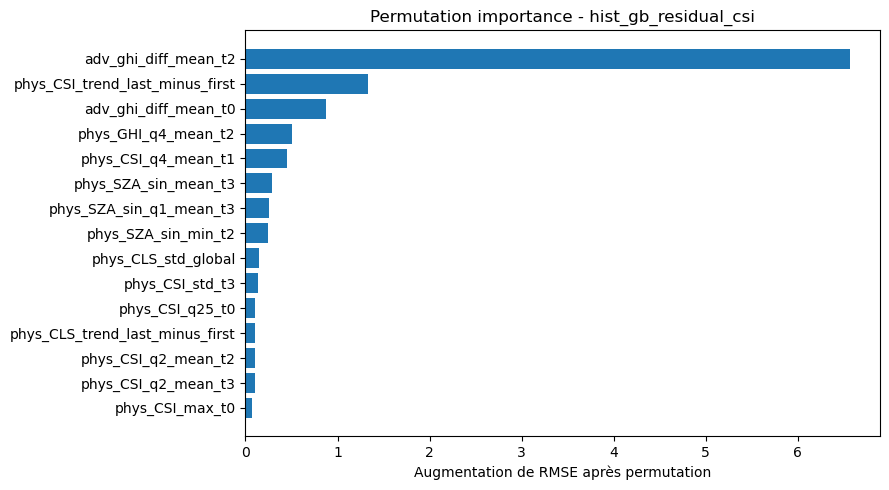

In [16]:
supervised_names = list(supervised_predictions)
supervised_scores = comparison_table[comparison_table["model"].isin(supervised_names)].copy()
best_supervised_name = supervised_scores.sort_values("RMSE").iloc[0]["model"]
best_supervised_model = model_registry[best_supervised_name]
print("Meilleur modèle supervisé:", best_supervised_name)

native_importances = model_feature_importances(best_supervised_model, feature_names)
if len(native_importances):
    display(native_importances.head(20))
else:
    print("Pas d'importance native disponible; permutation importance utilisée.")

perm = permutation_importance_multioutput(
    best_supervised_model,
    X_val_tab,
    residual_val,
    feature_names,
    n_repeats=3,
    random_state=RANDOM_STATE,
    max_features=40 if RUN_FAST else None,
)
display(perm.importance.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = perm.importance.head(15).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["importance_mean"])
ax.set_xlabel("Augmentation de RMSE après permutation")
ax.set_title(f"Permutation importance - {best_supervised_name}")
plt.tight_layout()
plt.show()

### Lecture des variables importantes

Les importances montrent que les variables les plus utiles sont liées à :
- la dynamique du CSI ;
- certaines statistiques de GHI ;
- certains résumés de l’angle solaire.

Si le CSI varie vite, cela signale un changement de nébulosité.

Si certains descripteurs de SZA apparaissent, cela veut dire que la géométrie solaire affecte encore le résidu ;
les statistiques spatiales de GHI traduisent l’état instantané du champ radiatif.

Le modèle n’utilise pas seulement le niveau d’irradiance, mais aussi des indices de variabilité spatiale et temporelle, ce qui est cohérent avec la dynamique des nuages.

L'analyse d'importance montre que les variables les plus utiles sont d'abord liées à la **dynamique récente du champ radiatif** (`adv_ghi_diff_mean_t2`, `phys_CSI_trend_last_minus_first`), puis à certaines statistiques spatiales locales (`quadrants`, quantiles), ainsi qu'à la géométrie solaire (`SZA`).

Cela indique que la performance du modèle repose avant tout sur la capacité à détecter si l'état nuageux est en train de se modifier rapidement. Cette lecture est cohérente avec la nature du problème : en nowcasting solaire, ce sont souvent les changements récents du champ nuageux qui contiennent l'information la plus prédictive sur les prochaines dizaines de minutes.

In [17]:
try:
    shap_values, X_shap, shap_feature_names = compute_tree_shap_values(
        best_supervised_model,
        X_val_tab,
        feature_names,
        output_index=0,
        max_samples=min(100, len(X_val_tab)),
    )
    print("SHAP calculé pour l'horizon t+15 sur", len(X_shap), "observations.")
except Exception as exc:
    print("SHAP non exécuté:", exc)
    print("Fallback conservé: permutation importance ci-dessus.")

c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP calculé pour l'horizon t+15 sur 100 observations.


In [20]:
shap_values, X_shap, shap_feature_names

(.values =
 array([[-0.0169987 ,  0.00421872, -0.00843586, ...,  0.        ,
          0.        ,  0.        ],
        [-0.02643571,  0.00653988, -0.00463991, ...,  0.        ,
          0.        ,  0.        ],
        [-0.0619558 , -0.00154873, -0.02111174, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.01576418,  0.01543563,  0.01937391, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.17266649,  0.02054731, -0.00643008, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.20831288,  0.02083807,  0.00630533, ...,  0.        ,
          0.        ,  0.        ]], shape=(100, 565))
 
 .base_values =
 array([0.10488303, 0.10488303, 0.10488303, 0.10488303, 0.10488303,
        0.10488303, 0.10488303, 0.10488303, 0.10488303, 0.10488303,
        0.10488303, 0.10488303, 0.10488303, 0.10488303, 0.10488303,
        0.10488303, 0.10488303, 0.10488303, 0.10488303, 0.10488303,
        0.10488303, 0.10488303, 0.10488303, 0.10488303,

### SHAP et cohérence avec l'importance par permutation

Le calcul SHAP confirme que l'interprétation du modèle ne repose pas sur une seule variable isolée, mais sur une combinaison de signaux de dynamique (`GHI`, `CSI`) et de contexte physique (`SZA`). Les résultats SHAP servent ici à consolider qualitativement les conclusions de la permutation importance.

L'objectif n'est pas de conclure sur une causalité stricte, mais de montrer que le modèle exploite des variables physiquement plausibles et cohérentes avec la dynamique attendue de l'irradiance solaire.

## 8. Deep Learning optionnel

Une CNN légère peut apprendre des cartes de résidus `y - persistence_csi` à partir du tenseur spatial. L'environnement actuel peut ne pas contenir TensorFlow; dans ce cas, on exécute une alternative MLP tabulaire pour conserver une preuve de concept rapide.

In [21]:
dl_predictions = {}

if has_tensorflow() and len(train_target) >= 16:
    X_cnn_train, y_cnn_train = prepare_cnn_training_data(
        spatial_train_tensor,
        train_target,
        baseline=y_pred_train_csi,
    )
    val_phys_for_cnn = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)
    spatial_val_tensor, _ = build_spatial_feature_tensor(val_phys_for_cnn)
    X_cnn_val, _ = prepare_cnn_training_data(
        spatial_val_tensor,
        val_target,
        baseline=y_pred_persistence_csi,
    )
    cnn = build_small_residual_cnn(
        input_shape=X_cnn_train.shape[1:],
        n_horizons=len(FORECAST_HORIZONS_MINUTES),
        learning_rate=1e-3,
    )
    history = cnn.fit(
        X_cnn_train,
        y_cnn_train,
        validation_split=0.2,
        epochs=3 if RUN_FAST else 20,
        batch_size=8,
        verbose=0,
    )
    residual_maps = target_from_channels_last(cnn.predict(X_cnn_val, verbose=0))
    y_pred_cnn = np.maximum(y_pred_persistence_csi + residual_maps, 0.0)
    dl_predictions["cnn_residual_csi"] = y_pred_cnn
    print("CNN exécutée.")
else:
    print("TensorFlow indisponible ou échantillon trop petit: fallback MLP tabulaire.")

mlp_model = fit_mlp_residual_mean(
    X_train_tab,
    residual_train,
    hidden_layer_sizes=(64, 32),
    random_state=RANDOM_STATE,
    max_iter=80 if RUN_FAST else 300,
)
mlp_residual = mlp_model.predict(X_val_tab)
dl_predictions["mlp_residual_csi"] = add_residual_mean_to_baseline(
    y_pred_persistence_csi,
    mlp_residual,
)

predictions.update(dl_predictions)
dl_table = pd.DataFrame(
    [
        global_metrics_row(name, val_target, pred, csi_reference_rmse)
        for name, pred in dl_predictions.items()
    ]
).sort_values("RMSE")
display(dl_table)

CNN exécutée.


,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,cnn_residual_csi,34.554623,13.837973,0.535798,3.880768,35.948378,0.07447,0.974882,4.813580,0.998934,0.016283
1,mlp_residual_csi,35.886574,17.471443,-7.651926,7.438782,41.205127,0.07734,0.972908,5.379726,0.998536,-0.061015


### Lecture de la baseline neuronale

Le MLP tabulaire testé ici constitue uniquement une baseline neuronale légère. Son objectif est de vérifier rapidement si un modèle non linéaire de type réseau peut extraire un signal utile à partir des features tabulaires.

Le résultat restant inférieur aux meilleurs modèles ensemblistes n'invalide pas l'approche deep learning : un vrai CNN entraîné sur tenseurs spatiaux est beaucoup mieux adapté à la structure image du problème.

## 9. Comparaison finale

La lecture principale se fait en deux temps: d'abord vérifier le skill score face à la persistance CSI, puis regarder la stabilité par horizon et par régime météo. Sur le profil `dev`, un skill négatif n'est pas forcément disqualifiant; sur `sample` ou `full`, il devient un signal fort.

In [22]:
final_table = pd.DataFrame(
    [
        global_metrics_row(name, val_target, pred, csi_reference_rmse)
        for name, pred in predictions.items()
    ]
).sort_values("RMSE").reset_index(drop=True)
display(final_table)

interesting = final_table.query("model != 'persistence_csi' and skill_RMSE_vs_CSI > 0")
if len(interesting):
    print("Modèles qui battent la persistance CSI:")
    display(interesting[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]])
else:
    print("Aucun modèle ne bat la persistance CSI sur ce run rapide.")

best_model_name = final_table.iloc[0]["model"]
print("Meilleur modèle global selon RMSE:", best_model_name)

cluster_perf = pd.concat(
    [
        metrics_by_cluster(
            val_target,
            y_pred_persistence_csi,
            val_clusters,
            "persistence_csi",
            cluster_name_map=cluster_name_map,
            reference_pred=y_pred_persistence_csi,
        ),
        metrics_by_cluster(
            val_target,
            predictions[best_supervised_name],
            val_clusters,
            best_supervised_name,
            cluster_name_map=cluster_name_map,
            reference_pred=y_pred_persistence_csi,
        ),
    ],
    ignore_index=True,
)
display(cluster_perf.sort_values(["cluster", "RMSE"]))

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,random_forest_residual_csi,34.119834,14.062523,-2.136755,4.278660,35.395886,0.073533,0.975510,4.646727,0.999325,4.088317e-02
1,extra_trees_residual_csi,34.226828,13.236339,-1.624564,2.944935,35.534778,0.073763,0.975356,4.622330,0.999289,3.485852e-02
2,elasticnet_residual_csi,34.306580,14.795970,4.916090,4.876907,35.444608,0.073935,0.975241,5.244503,0.999395,3.035550e-02
3,hist_gb_residual_csi,34.318004,13.703475,-0.881538,2.664444,35.730060,0.073960,0.975225,5.065669,0.999169,2.970962e-02
4,cnn_residual_csi,34.554623,13.837973,0.535798,3.880768,35.948378,0.074470,0.974882,4.813580,0.998934,1.628337e-02
5,persistence_csi,34.839439,14.050811,1.261249,4.200851,36.353549,0.075084,0.974466,4.945783,0.998765,8.238632e-12
6,ridge_residual_csi,35.086175,15.428085,-2.092205,4.203857,37.149280,0.075615,0.974103,5.100916,0.998571,-1.421432e-02
7,mlp_residual_csi,35.886574,17.471443,-7.651926,7.438782,41.205127,0.077340,0.972908,5.379726,0.998536,-6.101541e-02
8,persistence_raw,104.227141,85.046348,6.492757,72.599976,176.199982,0.224623,0.771475,39.946684,0.886094,-7.949924e+00
9,mean_image,231.218298,202.028227,-76.852982,221.514763,337.246213,0.498306,-0.124646,85.564558,0.022568,-4.304556e+01


Modèles qui battent la persistance CSI:


,model,RMSE,MAE,skill_RMSE_vs_CSI
0,random_forest_residual_csi,34.119834,14.062523,0.040883
1,extra_trees_residual_csi,34.226828,13.236339,0.034859
2,elasticnet_residual_csi,34.306580,14.795970,0.030355
3,hist_gb_residual_csi,34.318004,13.703475,0.029710
4,cnn_residual_csi,34.554623,13.837973,0.016283


Meilleur modèle global selon RMSE: random_forest_residual_csi


,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
2,random_forest_residual_csi,0,partiellement_nuageux,44,26.629175,10.579821,-2.548320,20.864246,0.055339,1.334883e-02
0,persistence_csi,0,partiellement_nuageux,44,26.808709,10.260291,0.693848,21.113281,0.055712,1.391387e-11
3,random_forest_residual_csi,1,couvert,8,60.555253,33.217388,0.126851,94.880135,0.163901,6.853057e-02
1,persistence_csi,1,couvert,8,62.743323,34.898674,4.381958,98.649803,0.169823,2.540190e-12


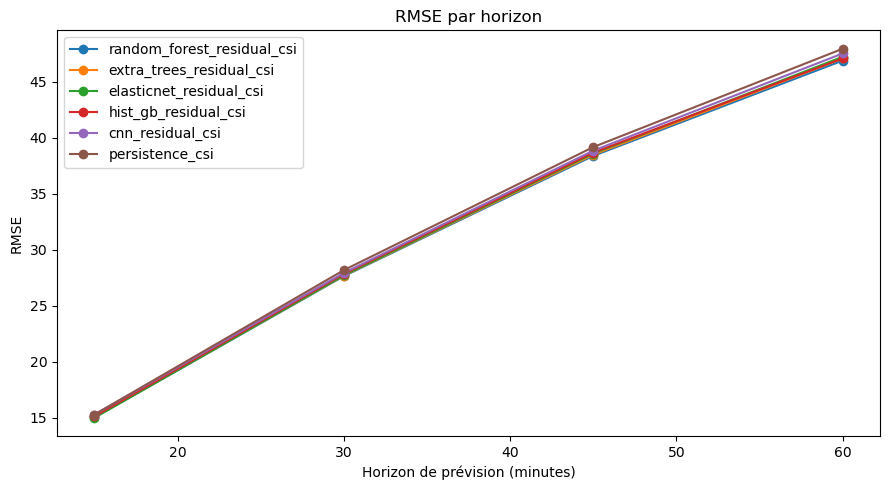

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_models = [name for name in final_table["model"].head(6)]
for model_name in plot_models:
    h = evaluate_by_horizon(val_target, predictions[model_name])
    ax.plot(h["horizon_min"], h["RMSE"], marker="o", label=model_name)
ax.set_xlabel("Horizon de prévision (minutes)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE par horizon")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion opérationnelle

La persistance CSI est la baseline à battre: elle exploite déjà la physique clear-sky et donne une structure spatiale cohérente. Les modèles simples deviennent intéressants seulement s'ils corrigent systématiquement ses erreurs, ce que le skill score RMSE mesure directement.

Pour la version finale à rendre, les priorités sont:

- relancer ce notebook en `sample`, puis `full`;
- élargir la grille HistGB autour des meilleurs paramètres;
- conserver l'analyse par cluster pour montrer dans quels régimes le modèle apporte de la valeur;
- installer `shap` si possible pour compléter la permutation importance;
- exécuter la CNN seulement si un environnement TensorFlow/PyTorch est disponible.

les modèles tabulaires améliorent la calibration du niveau global, mais pas la géométrie fine du champ radiatif.